 **TP1 : Les statistiques avec python
Manipulation des données avec Pandas**

L’objectif de ce premier TP est de vous familiariser avec la manipulation des données, la réalisation
des calculs statistiques simples (statistiques descriptives) et introduire quelques packages Python fonda-
mentaux, indispensables pour l’analyse des données : pandas (bibliothèque permettant les opérations de
manipulation de tableaux et l’analyse des données), numpy (destinée à manipuler des matrices ou tableaux
multidimensionnels et les fonctions mathématiques opérant sur ces tableaux), matplotlib (destinée à tracer
et visualiser des données sous formes de graphiques) etc.

**Chargement des données et structure Data.frame**

Lancez Jupyter, créez un nouveau ficher et modifiez le répertoire par défaut.
Importez la librairie Pandas.
Importez le fichier « voitures.xlsx » dans un Data frame.

In [2]:
#pour vérifier le répertoire courante
import os
os.getcwd()

'/content'

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Notes.xlsx to Notes.xlsx


In [4]:
!ls

Notes.xlsx  sample_data


In [ ]:
import xlrd
import pandas
#chargement de la première feuille de données,
#première ligne avec noms des variables
#et première colonne identifiant des individus
X = pandas.read_excel("/content/Notes.xlsx",sheet_name="Feuil2",header=0,index_col=0)
#affichage des données
print(X.shape)
print(X)

(103, 11)
         SE    ASE  ALGA     PJ   TWA     RE   ROO     CE    TE   TRE  Gp
Ind                                                                      
E1    14.00  13.98  15.0  17.00  15.0  12.20  10.0   9.50  17.0  14.0  GA
E2    12.90   6.38  15.0  11.00  14.0   4.25   6.0   4.75  13.0  11.3  GA
E3    14.60  14.60  14.5  18.75  16.0  14.40  10.0  12.50  16.5  15.6  GA
E4    16.15  18.00  10.5  17.75  15.0  14.80  13.0  14.00  14.0  11.5  GA
E5    17.30  17.83  18.0  18.25  15.0  15.60  14.5  16.00  14.0  11.2  GA
...     ...    ...   ...    ...   ...    ...   ...    ...   ...   ...  ..
E99   12.50  14.25  11.5  10.38  13.0  13.75   9.5   2.50  10.0  12.4  GD
E100  13.50  19.75   2.0  12.00  10.0   6.50  10.0   7.00  13.0  12.3  GD
E101  13.00   9.75  17.0  16.50  17.5   9.20  16.5   8.50  16.5  13.7  GD
E102  17.25  13.25   8.0  16.25  12.5  11.20  11.2  13.00  13.5  12.2  GD
E103  19.00  11.50   7.0  16.88  10.0  10.60  13.6  10.00  99.0  15.3  GD

[103 rows x 11 columns]


# Nouvelle section

**Description des données**

Combien y a-t-il d'individus et de variables dans le fichier ?
Notez bien les noms des variables.
Affichez les statistiques élémentaires concernant l'ensemble de données importées (describe).

In [10]:
#dimension
print(X.shape)
#nombre d'individus
n = X.shape[0]
#nombre de variables
p = X.shape[1]
print(n)
print(p)

#afficher les premières lignes du jeu de données
print(X.head())

#description des données
print(X.describe(include='all'))

(103, 11)
103
11
        SE    ASE  ALGA     PJ   TWA     RE   ROO     CE    TE   TRE  Gp
Ind                                                                     
E1   14.00  13.98  15.0  17.00  15.0  12.20  10.0   9.50  17.0  14.0  GA
E2   12.90   6.38  15.0  11.00  14.0   4.25   6.0   4.75  13.0  11.3  GA
E3   14.60  14.60  14.5  18.75  16.0  14.40  10.0  12.50  16.5  15.6  GA
E4   16.15  18.00  10.5  17.75  15.0  14.80  13.0  14.00  14.0  11.5  GA
E5   17.30  17.83  18.0  18.25  15.0  15.60  14.5  16.00  14.0  11.2  GA
                SE         ASE        ALGA          PJ         TWA  \
count   103.000000  103.000000  103.000000  103.000000  103.000000   
unique         NaN         NaN         NaN         NaN         NaN   
top            NaN         NaN         NaN         NaN         NaN   
freq           NaN         NaN         NaN         NaN         NaN   
mean     14.734951   14.463107   11.750000   15.904757   16.014563   
std       2.855188    3.582716    4.817376    2.8743

**Manipulation des variables**

Il est possible d’accéder explicitement aux variables en utilisant directement les noms des champs (les noms des variables, en en-tête de colonne)

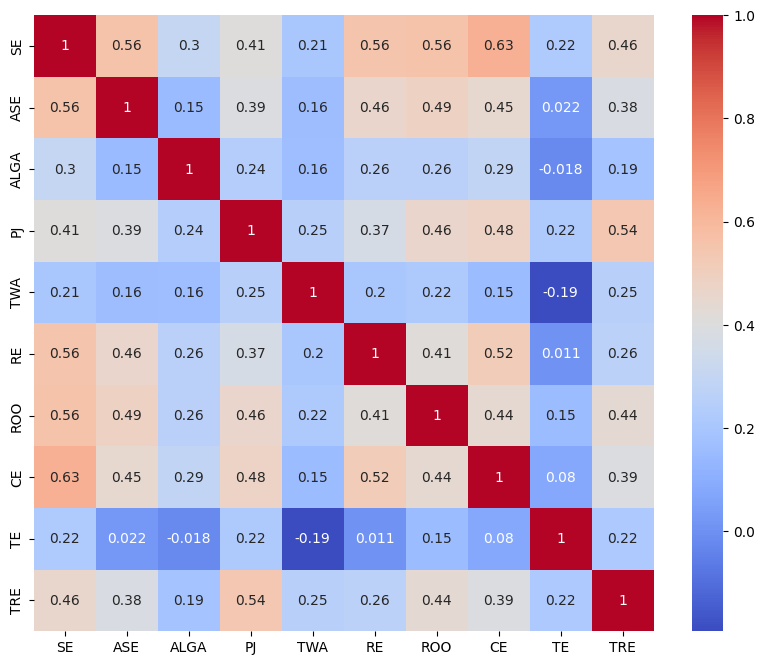

In [14]:

corr = X.select_dtypes(include="number").corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

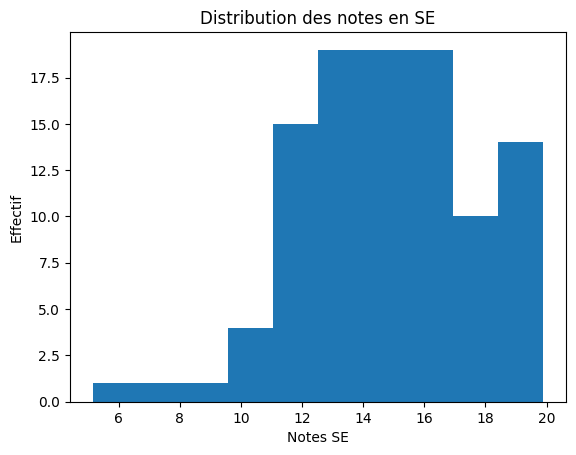

In [15]:
import matplotlib.pyplot as plt

plt.hist(X["SE"], bins=10)
plt.xlabel("Notes SE")
plt.ylabel("Effectif")
plt.title("Distribution des notes en SE")
plt.show()

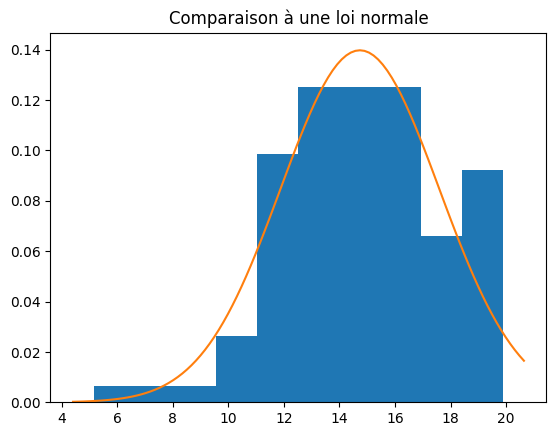

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data = X["SE"]

# paramètres estimés
mu = data.mean()
sigma = data.std()

# histogramme normalisé
plt.hist(data, bins=10, density=True)

# courbe normale théorique
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)

plt.plot(x, p)
plt.title("Comparaison à une loi normale")
plt.show()

In [17]:
table_groupe = X.groupby("Gp").mean()
table_groupe

,SE,ASE,ALGA,PJ,TWA,RE,ROO,CE,TE,TRE
Gp,,,,,,,,,,
GA,14.723077,14.354615,13.442308,16.269231,16.634615,12.675000,12.209615,8.663462,15.596154,13.126923
GB,14.015385,14.031154,8.826923,15.653846,15.250000,11.559615,12.323077,9.846154,14.346154,12.030769
GC,14.711538,14.613846,13.605769,15.336538,17.173077,11.544231,12.253846,10.884615,14.538462,13.546154
GD,15.520000,14.868400,11.100000,16.377600,14.960000,12.600000,12.604000,9.900000,18.420000,13.628000


In [18]:
X[X["Gp"] == "GA"].describe()

,SE,ASE,ALGA,PJ,TWA,RE,ROO,CE,TE,TRE
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,14.723077,14.354615,13.442308,16.269231,16.634615,12.675000,12.209615,8.663462,15.596154,13.126923
std,2.718685,4.018826,3.390655,2.132983,1.646558,3.047302,3.139969,4.871828,1.463005,1.681798
min,8.750000,5.500000,7.000000,10.250000,14.000000,4.250000,5.500000,1.000000,13.000000,9.600000
25%,13.137500,12.187500,10.625000,15.312500,15.000000,11.300000,10.425000,5.000000,14.125000,11.625000
50%,14.675000,15.440000,14.375000,16.500000,16.500000,12.700000,12.500000,9.750000,16.000000,13.700000
75%,16.787500,17.625000,15.000000,17.937500,18.500000,14.700000,14.375000,12.375000,17.000000,14.275000
max,19.450000,20.000000,19.250000,19.000000,18.500000,18.000000,17.400000,17.000000,18.000000,15.600000


Comparaison par matière

In [22]:
# Groupe GA
GA = X[X["Gp"] == "GA"]

# Moyennes par matière pour le groupe
moyennes_GA = GA.select_dtypes(include="number").mean()

# Moyennes par matière pour l'ensemble des étudiants
moyennes_totales = X.select_dtypes(include="number").mean()

print("Moyennes Groupe GA :\n", moyennes_GA)
print("\nMoyennes Totales :\n", moyennes_totales)
#Calcul des écarts
ecart = moyennes_GA - moyennes_totales
print("Écart Groupe GA vs Ensemble :\n", ecart)


Moyennes Groupe GA :
 SE      14.723077
ASE     14.354615
ALGA    13.442308
PJ      16.269231
TWA     16.634615
RE      12.675000
ROO     12.209615
CE       8.663462
TE      15.596154
TRE     13.126923
dtype: float64

Moyennes Totales :
 SE      14.734951
ASE     14.463107
ALGA    11.750000
PJ      15.904757
TWA     16.014563
RE      12.089806
ROO     12.345146
CE       9.822816
TE      15.699029
TRE     13.077670
dtype: float64
Écart Groupe GA vs Ensemble :
 SE     -0.011875
ASE    -0.108491
ALGA    1.692308
PJ      0.364473
TWA     0.620052
RE      0.585194
ROO    -0.135530
CE     -1.159354
TE     -0.102875
TRE     0.049253
dtype: float64


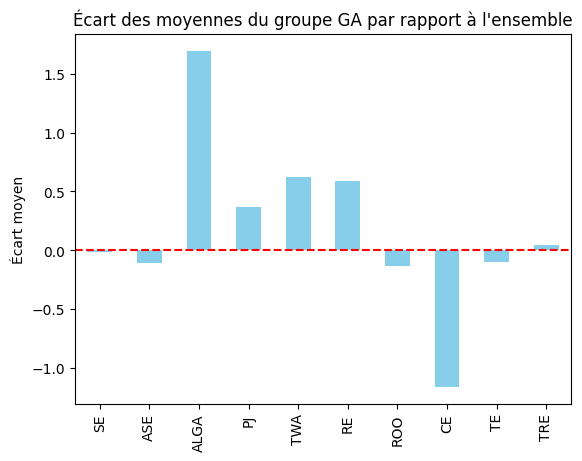

In [23]:
#Visualisation
import matplotlib.pyplot as plt

ecart.plot(kind="bar", color="skyblue")
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Écart moyen")
plt.title("Écart des moyennes du groupe GA par rapport à l'ensemble")
plt.show()
#Barres au-dessus de 0 → matières où GA est meilleur:Matières où le groupe GA dépasse l’ensemble des groupes
#Barres en dessous de 0 → matières où GA est moins performant
#Écart négatif → matières à améliorer
#Les écarts supérieurs à 1 ou 2 points peuvent être considérés comme significatifs